In [ ]:
from lgdo import lh5
import os
import awkward as ak
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
dirname = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vary_current_shaping/01smooth/phy"
flist = sorted(os.listdir(dirname))
flist[0]

'p00'

In [3]:
pathlist = [os.path.join(dirname, f) for f in flist]
pathlist

['/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vary_current_shaping/01smooth/phy/p00',
 '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vary_current_shaping/01smooth/phy/p05',
 '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vary_current_shaping/01smooth/phy/p06']

In [4]:
pathlist[0]

'/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vary_current_shaping/01smooth/phy/p00'

In [5]:
lh5.show(pathlist[0])

LH5DecodeError: while opening file /mnt/atlas01/users/vogl/scarf/sp01/data/hit_vary_current_shaping/01smooth/phy/p00 for decoding: [Errno 21] Unable to synchronously open file (file read failed: time = Thu Feb 26 23:25:37 2026
, filename = '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vary_current_shaping/01smooth/phy/p00', file descriptor = 68, errno = 21, error message = 'Is a directory', buf = 0x7ffe2a82f638, total read size = 8, bytes this sub-read = 8, offset = 0)

In [ ]:
obj = lh5.read("ch001/hit", pathlist)
obj2 = lh5.read("ch002/hit", pathlist)

In [ ]:
obj.view_as("ak")

<Array [{Amax_o_E_Classifier: nan, ...}, ...] type='2292780 * {Amax_o_E_Cla...'>

In [ ]:
obj.view_as("pd")

,Amax_o_E_Classifier,Amax_o_E_Corrected,Amax_o_E_Double_Sided_Cut,Amax_o_E_High_Side_Cut,Amax_o_E_Low_Cut,Amax_o_E_Timecorr,Amax_o_E_Uncorr,Amaxmw_o_E_Classifier,Amaxmw_o_E_Corrected,Amaxmw_o_E_Double_Sided_Cut,...,is_valid_bl,is_valid_bl_slope,is_valid_bl_slope_rms,is_valid_leading_edge,is_valid_tail,is_valid_tail_rms,is_valid_waveform,timestamp,trapEftp_cal,trapEmax_cal
0,NaN,-11.432716,False,False,False,-11.501083,-0.504663,NaN,-19.007072,False,...,True,True,True,True,True,True,True,1.698336e+09,-5.162585,1.080797
1,NaN,-22.101802,False,False,False,-22.233715,-0.975606,NaN,-35.938415,False,...,True,True,True,True,True,True,True,1.698336e+09,-2.687461,0.247182
2,7.321975,80.617988,False,False,True,81.095855,3.558453,13.400386,74.423663,False,...,True,True,True,False,True,True,False,1.698336e+09,6.116697,5.697974
3,-0.815894,0.989874,True,True,True,0.988171,0.043361,-0.031737,0.999425,True,...,True,True,True,True,True,True,True,1.698336e+09,1652.689810,1653.084491
4,9.012028,44.538587,False,False,True,44.801425,1.965868,15.315166,43.456823,False,...,True,True,True,False,True,True,False,1.698336e+09,11.757289,10.906401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2292775,0.318285,1.032191,True,True,True,1.037067,0.045506,2.097903,1.226792,True,...,True,True,True,True,True,True,True,1.698417e+09,265.396967,265.490394
2292776,-0.561861,0.950127,True,True,True,0.954485,0.041882,-0.240604,0.976682,True,...,True,True,True,True,True,True,True,1.698417e+09,295.003696,294.862821
2292777,NaN,-5.219066,False,False,False,-5.250472,-0.230389,NaN,-7.147342,False,...,False,False,True,True,True,True,False,1.698417e+09,-13.272308,3.687322
2292778,NaN,-36.240217,False,False,False,-36.457261,-1.599730,NaN,-13.639006,False,...,True,True,True,True,True,True,True,1.698417e+09,-7.122865,1.129654


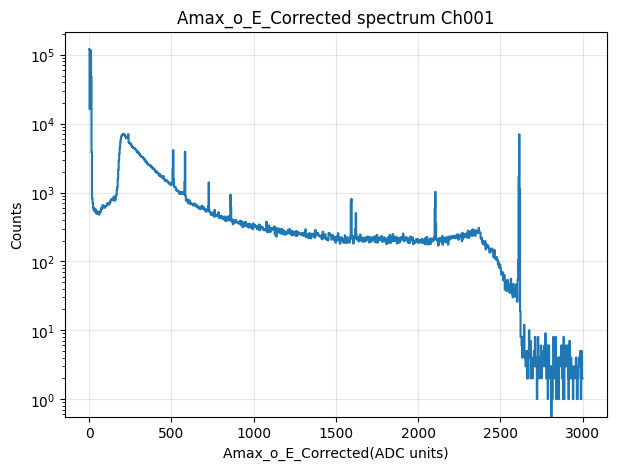

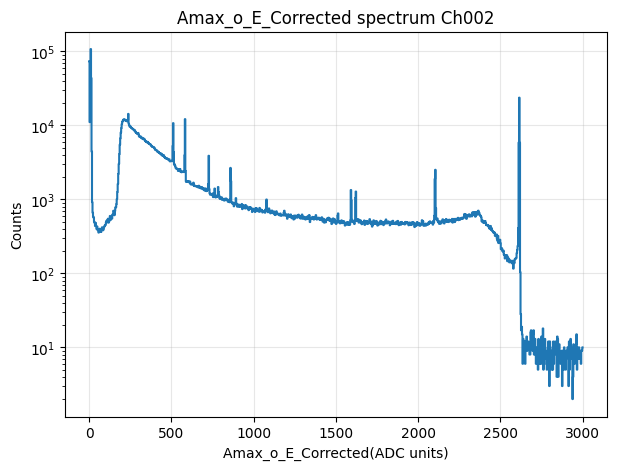

In [ ]:
ak_hit = obj.view_as("ak")
ak_hit2 = obj2.view_as("ak")
type(ak_hit["trapEftp_cal"])
E_max = ak_hit["trapEftp_cal"]
E_max2 = ak_hit2["trapEftp_cal"]
# # E_max = ak.drop_none(E_max)
# # E_max_np = ak.to_numpy(E_max)

# histogram
hist, edges = np.histogram(E_max, bins=1000,range=(0,3000))

# plot
centers = 0.5 * (edges[:-1] + edges[1:])
plt.figure(figsize=(7,5))
plt.step(centers, hist, where="mid")
plt.yscale("log")
plt.xlabel("Amax_o_E_Corrected(ADC units)")
plt.ylabel("Counts")
plt.title("Amax_o_E_Corrected spectrum Ch001")
plt.grid(alpha=0.3)
plt.show()
hist2, edges2 = np.histogram(E_max2, bins=1000,range=(0,3000))
centers2 = 0.5 * (edges2[:-1] + edges2[1:]) 
plt.figure(figsize=(7,5))
plt.step(centers2, hist2, where="mid")
plt.yscale("log")
plt.xlabel("Amax_o_E_Corrected(ADC units)")
plt.ylabel("Counts")
plt.title("Amax_o_E_Corrected spectrum Ch002")
plt.grid(alpha=0.3)
plt.show()  


## Channel1

In [ ]:
from scipy.signal import find_peaks

# Search windows (ADC units!)
k42_window = (centers2 > 1500) & (centers2 < 1700)
tl208_window = (centers2 > 2500) & (centers2 < 2700)
k42_slice = hist2[k42_window]
k42_peak_idx = np.argmax(k42_slice)
k42_peak_adc = centers2[k42_window][k42_peak_idx]
print("K42 peak ADC:", k42_peak_adc)

tl208_slice = hist2[tl208_window]
tl208_peak_idx = np.argmax(tl208_slice)
tl208_peak_adc = centers2[tl208_window][tl208_peak_idx]

print("Tl208 peak ADC:", tl208_peak_adc)

print(k42_peak_adc, tl208_peak_adc)
E_k42   = 1524.7   # keV
E_tl208 = 2614.5   # keV

adc_peaks = np.array([k42_peak_adc, tl208_peak_adc])
keV_peaks = np.array([E_k42, E_tl208])

a, b = np.polyfit(adc_peaks, keV_peaks, 1)

print("Calibration:")
print("E_keV = {:.4f} * ADC + {:.2f}".format(a, b))

dep_adc_pred = (1592.5 - b) / a
print("Predicted DEP ADC:", dep_adc_pred)
E_dep = 1592.5   # keV

K42 peak ADC: 1591.5
Tl208 peak ADC: 2614.5
1591.5 2614.5
Calibration:
E_keV = 1.0653 * ADC + -170.72
Predicted DEP ADC: 1655.1441548908042


In [ ]:
dep_window = (centers2 > 1600) & (centers2 < 1700)
dep_slice = hist[dep_window]
dep_peak_idx = np.argmax(dep_slice)
dep_peak_adc = centers[dep_window][dep_peak_idx]
print("DEP peak ADC:", dep_peak_adc)

DEP peak ADC: 1621.5


In [ ]:
DEP_width_adc = 20
tl208_width_adc = 30
DEP_mask = (
    (E_max > dep_peak_adc-DEP_width_adc) &
    (E_max < dep_peak_adc + DEP_width_adc)
)

tl208_mask = (
    (E_max > tl208_peak_adc-10) &
    (E_max < tl208_peak_adc + tl208_width_adc)
)

E_uperlim = (2239 - b) / a
E_lowerlim = (1839 - b) / a
Energy_mask = (
    (E_max > E_lowerlim) &
    (E_max < E_uperlim)
)


# AoverE

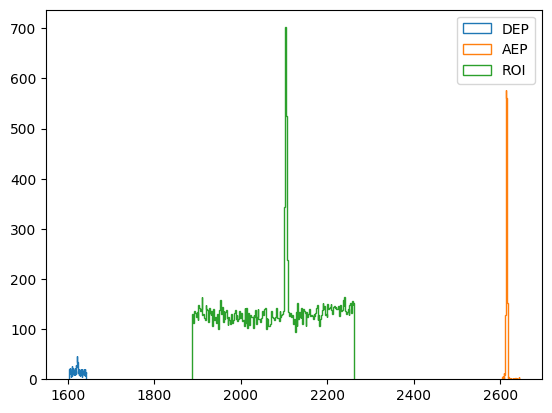

In [ ]:
plt.hist(E_max[DEP_mask], bins=200, histtype="step", label="DEP")
plt.hist(E_max[tl208_mask], bins=200, histtype="step", label="AEP")
plt.hist(E_max[Energy_mask], bins=200, histtype="step", label="ROI")
plt.legend()
plt.show()



Number of aoe entries: 3226


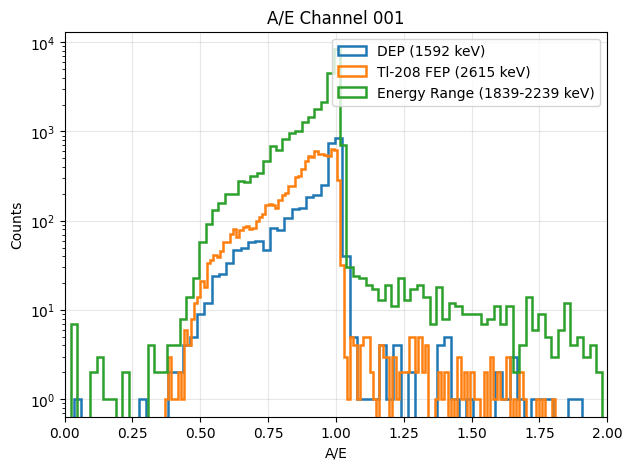

In [ ]:

aoe_dep = ak_hit["Amax_o_E_Corrected"][DEP_mask]
aoe_tl208 = ak_hit["Amax_o_E_Corrected"][tl208_mask]
aoe_energyrange = ak_hit["Amax_o_E_Corrected"][Energy_mask]
print("Number of aoe entries:", len(aoe_dep))


plt.figure(figsize=(7,5))
plt.title("A/E Channel 001")
plt.hist(
    aoe_dep,
    bins=200,
    histtype="step",
    linewidth=1.8,
    label="DEP (1592 keV)"
)

plt.hist(
    aoe_tl208,
    bins=200,
    histtype="step",
    linewidth=1.8,
    label="Tl-208 FEP (2615 keV)"
)
plt.hist(   
    aoe_energyrange,
    bins=200,
    histtype="step",
    linewidth=1.8,
    label="Energy Range (1839-2239 keV)"
)
plt.xlabel("A/E")
plt.ylabel("Counts")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 2)

plt.show()

## Channel2

In [ ]:
from scipy.signal import find_peaks

# Search windows (ADC units!)
k42_window2 = (centers > 1500) & (centers < 1700)
tl208_window2 = (centers > 2500) & (centers < 2700)
k42_slice = hist[k42_window]
k42_peak_idx = np.argmax(k42_slice)
k42_peak_adc = centers[k42_window][k42_peak_idx]

print("K42 peak ADC:", k42_peak_adc)

tl208_slice = hist[tl208_window]
tl208_peak_idx = np.argmax(tl208_slice)
tl208_peak_adc = centers[tl208_window][tl208_peak_idx]

print("Tl208 peak ADC:", tl208_peak_adc)

print(k42_peak_adc, tl208_peak_adc)
E_k42   = 1524.7   # keV
E_tl208 = 2614.5   # keV

adc_peaks = np.array([k42_peak_adc, tl208_peak_adc])
keV_peaks = np.array([E_k42, E_tl208])

a, b = np.polyfit(adc_peaks, keV_peaks, 1)

print("Calibration:")
print("E_keV = {:.4f} * ADC + {:.2f}".format(a, b))

dep_adc_pred = (1592.5 - b) / a
print("Predicted DEP ADC:", dep_adc_pred)
E_dep = 1592.5   # keV

K42 peak ADC: 1594.5
Tl208 peak ADC: 2614.5
1594.5 2614.5
Calibration:
E_keV = 1.0684 * ADC + -178.91
Predicted DEP ADC: 1657.9575151403924


In [ ]:
dep_window = (centers2 > 1600) & (centers2 < 1700)
dep_slice = hist[dep_window]
dep_peak_idx = np.argmax(dep_slice)
dep_peak_adc = centers[dep_window][dep_peak_idx]
print("DEP peak ADC:", dep_peak_adc)

DEP peak ADC: 1621.5


In [ ]:
DEP_width_adc = 20
tl208_width_adc = 30
DEP_mask = (
    (E_max2 > dep_peak_adc-DEP_width_adc) &
    (E_max2 < dep_peak_adc + DEP_width_adc)
)

tl208_mask = (
    (E_max2 > tl208_peak_adc-10) &
    (E_max2 < tl208_peak_adc + tl208_width_adc)
)

E_uperlim = (2239 - b) / a
E_lowerlim = (1839 - b) / a
Energy_mask = (
    (E_max2 > E_lowerlim) &
    (E_max2 < E_uperlim)
)

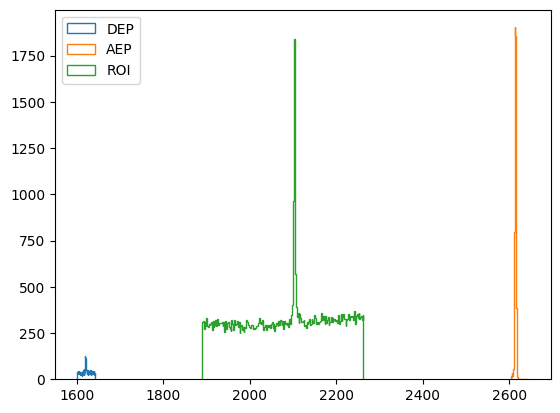

In [ ]:
plt.hist(E_max2[DEP_mask], bins=200, histtype="step", label="DEP")
plt.hist(E_max2[tl208_mask], bins=200, histtype="step", label="AEP")
plt.hist(E_max2[Energy_mask], bins=200, histtype="step", label="ROI")
plt.legend()
plt.show()


Number of aoe entries: 8107


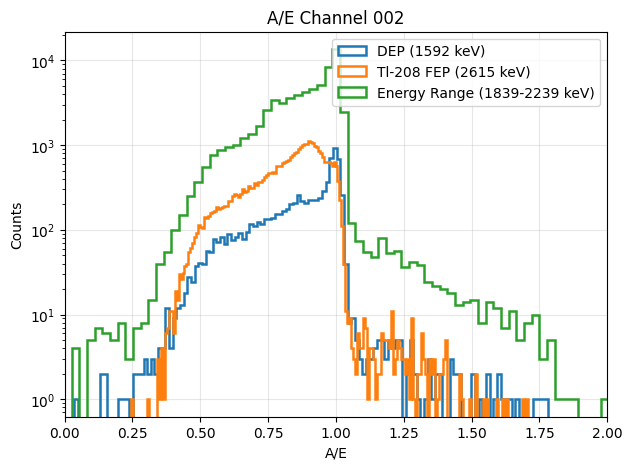

In [ ]:

aoe_dep = ak_hit2["Amax_o_E_Corrected"][DEP_mask]
aoe_tl208 = ak_hit2["Amax_o_E_Corrected"][tl208_mask]
aoe_energyrange = ak_hit2["Amax_o_E_Corrected"][Energy_mask]
print("Number of aoe entries:", len(aoe_dep))


plt.figure(figsize=(7,5))
plt.title("A/E Channel 002")
plt.hist(
    aoe_dep,
    bins=200,
    histtype="step",
    linewidth=1.8,
    label="DEP (1592 keV)"
)

plt.hist(
    aoe_tl208,
    bins=200,
    histtype="step",
    linewidth=1.8,
    label="Tl-208 FEP (2615 keV)"
)
plt.hist(   
    aoe_energyrange,
    bins=200,
    histtype="step",
    linewidth=1.8,
    label="Energy Range (1839-2239 keV)"
)
plt.xlim(0, 2)
plt.xlabel("A/E")
plt.ylabel("Counts")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)

plt.show()